# Notebook 04 — Comparativo das 3 Visões e Cross-Domain

Este notebook segue rigorosamente o pipeline de treinamento e avaliação dos notebooks 01 e 02, adaptado para a metodologia das 3 Visões:
1. **Visão 1 (Real -> Real):** Treino e teste em dados orgânicos.
2. **Visão 2 (Sintético -> Sintético):** Treino e teste em dados gerados por LLMs.
3. **Visão 3 (Sintético -> Real):** Avaliação do *Reality Gap*.

**Compatível com Local (VS Code) e Google Colab.**

In [13]:
# 0. SETUP: Detecção de Ambiente e Instalação
import os, sys, re, glob, shutil

# Instalação de dependências ausentes (Garante o kagglehub no ambiente local)
try:
    import kagglehub
    import ipywidgets
except ImportError:
    print("Instalando kagglehub, ipywidgets e dependências...")
    !{sys.executable} -m pip install kagglehub ipywidgets -q --break-system-packages
    print("✅ Instalação concluída!")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Ambiente: Google Colab")
    REPO_URL = 'https://github.com/ROMAUSKI/tcc-analise-sentimento.git'
    if not os.path.exists('tcc-analise-sentimento'):
        !git clone $REPO_URL
    os.chdir('tcc-analise-sentimento')
else:
    print("Ambiente: Local (VS Code)")
    if os.getcwd().endswith('src'):
        os.chdir('..')

sns.set_style('whitegrid')
print(f"Diretório atual: {os.getcwd()}")

Ambiente: Local (VS Code)
Diretório atual: c:\Users\Davi\Documentos\tcc-analise-sentimento


In [14]:
# 1. CONFIGURAÇÃO (IDENTICA AOS NOTEBOOKS ORIGINAIS)
NICHO = 'movies' # Mude para 'apps' quando os dados brutos de apps estiverem prontos

CONFIG = {
    'movies': {
        'raw_synth': 'dados/brutos/',
        'real_file': 'src/dados_reais/utlc_movies.csv'
    },
    'apps': {
        'raw_synth': 'dados/brutos_apps/',
        'real_file': 'src/dados_reais/utlc_apps.csv'
    }
}

RANDOM_SEED = 42 # Mesma seed do notebook 01
os.makedirs('resultados', exist_ok=True)
os.makedirs('src/dados_reais', exist_ok=True)

In [15]:
# 2. UNIFICAÇÃO E LIMPEZA (FUNÇÃO ORIGINAL DO NOTEBOOK 01)
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-zÀ-ÿ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def unificar_e_processar(nicho_nome):
    pasta = CONFIG[nicho_nome]['raw_synth']
    arquivos = glob.glob(os.path.join(pasta, '*.csv'))
    arquivos = [f for f in arquivos if all(x not in f for x in ['metadata', 'dataset', 'synthetic'])]
    
    lista = []
    for f in arquivos:
        nome = os.path.basename(f).lower()
        # Identifica classe e fonte pelo nome do arquivo
        classe = 'Positiva' if 'positive' in nome else ('Negativa' if 'negative' in nome else 'Neutra')
        fonte = 'ChatGPT' if 'gpt' in nome else ('Claude' if 'claude' in nome else 'Gemini')
        
        df_temp = pd.read_csv(f, header=None, names=['frase'], usecols=[0])
        df_temp['classe'] = classe
        df_temp['fonte'] = fonte
        lista.append(df_temp)
    
    df = pd.concat(lista, ignore_index=True)
    df['frase_limpa'] = df['frase'].apply(limpar_texto)
    df = df.drop_duplicates(subset=['frase_limpa']).reset_index(drop=True)
    return df

df_sintetico = unificar_e_processar(NICHO)
print(f"Dataset Sintético ({NICHO}) processado: {len(df_sintetico)} amostras.")

Dataset Sintético (movies) processado: 1800 amostras.


In [16]:
# 3. DOWNLOAD E PREPARAÇÃO DOS DADOS REAIS
# O que esta célula faz:
# 1. Carrega uma fração do dataset real (para evitar travamento por falta de memória).
# 2. Mapeia as notas (ratings) originais para as classes Positiva, Negativa e Neutra.
# 3. Limpa os textos e remove avaliações que ficaram vazias.
# 4. Aplica um balanceamento rigoroso: como as avaliações neutras costumam ser minoria,
#    o código descobre qual é a classe com menos amostras e sorteia a exata mesma
#    quantidade para as demais. Isso descarta o excesso e garante um dataset final
#    perfeitamente equilibrado, impedindo que o modelo fique enviesado.
import kagglehub
path_real = CONFIG[NICHO]['real_file']

if not os.path.exists(path_real):
    print(f"Baixando dataset real via kagglehub...")
    d_path = kagglehub.dataset_download("fredericods/ptbr-sentiment-analysis-datasets")
    shutil.copy(os.path.join(d_path, os.path.basename(path_real)), path_real)

df_real_raw = pd.read_csv(path_real, nrows=100000)
def mapper(rating):
    if rating >= 4: return 'Positiva'
    elif rating <= 2: return 'Negativa'
    else: return 'Neutra'

df_real_raw['classe'] = df_real_raw['rating'].apply(mapper)
df_real = df_real_raw[['review_text', 'classe']].dropna()
df_real.columns = ['frase', 'classe']
df_real['frase_limpa'] = df_real['frase'].apply(limpar_texto)
df_real = df_real[df_real['frase_limpa'] != ""]

# Balanceamento manual
min_size = df_real['classe'].value_counts().min()
df_real_bal = df_real.groupby('classe').sample(n=min_size, random_state=RANDOM_SEED)
print(f"Dataset Real ({NICHO}) balanceado: {len(df_real_bal)} amostras.")

Dataset Real (movies) balanceado: 27687 amostras.


In [17]:
# 4. EXECUÇÃO DAS 3 VISÕES (IDENTICO AO MODO DE TREINAR DO NOTEBOOK 01)
def run_vision(X_train, y_train, X_test, y_test, visao_nome):
    results = []
    # Modelos com os mesmos nomes e params do 01
    modelos = {
        'Regressão Logística': LogisticRegression(random_state=RANDOM_SEED),
        'Naive Bayes': MultinomialNB(),
        'SVM Linear': LinearSVC(random_state=RANDOM_SEED, max_iter=5000)
    }
    
    # TfidfVectorizer PADRÃO (sem params extras)
    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    
    print(f"\n--- {visao_nome} ---")
    for nome, clf in modelos.items():
        clf.fit(X_train_tfidf, y_train)
        y_pred = clf.predict(X_test_tfidf)
        
        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
        
        print(f"{nome}: F1={f1:.2%}")
        results.append({
            'Modelo': nome, 
            'Visão': visao_nome, 
            'Acurácia': acc, 
            'Precisão': prec, 
            'Recall': rec, 
            'F1-Score': f1
        })
    return results

final_metrics = []

# V1: Real -> Real (Split 80/20)
R_tr, R_te = train_test_split(df_real_bal, test_size=0.2, stratify=df_real_bal['classe'], random_state=RANDOM_SEED)
final_metrics += run_vision(R_tr['frase_limpa'], R_tr['classe'], R_te['frase_limpa'], R_te['classe'], "V1: Real -> Real")

# V2: Sintético -> Sintético (Split 80/20)
S_tr, S_te = train_test_split(df_sintetico, test_size=0.2, stratify=df_sintetico['classe'], random_state=RANDOM_SEED)
final_metrics += run_vision(S_tr['frase_limpa'], S_tr['classe'], S_te['frase_limpa'], S_te['classe'], "V2: Sint. -> Sint.")

# V3: Sintético -> Real (Train 100% Sint, Test 100% Real)
final_metrics += run_vision(df_sintetico['frase_limpa'], df_sintetico['classe'], df_real_bal['frase_limpa'], df_real_bal['classe'], "V3: Sint. -> Real")


--- V1: Real -> Real ---
Regressão Logística: F1=58.05%
Naive Bayes: F1=57.03%
SVM Linear: F1=54.52%

--- V2: Sint. -> Sint. ---
Regressão Logística: F1=87.22%
Naive Bayes: F1=88.65%
SVM Linear: F1=89.15%

--- V3: Sint. -> Real ---
Regressão Logística: F1=39.94%
Naive Bayes: F1=38.77%
SVM Linear: F1=40.24%



--- TABELA DE MÉTRICAS CONSOLIDADAS ---


,Modelo,Visão,Acurácia,Precisão,Recall,F1-Score
0,Regressão Logística,V1: Real -> Real,0.5825,0.5792,0.5825,0.5805
1,Naive Bayes,V1: Real -> Real,0.5672,0.5768,0.5672,0.5703
2,SVM Linear,V1: Real -> Real,0.5473,0.5438,0.5473,0.5452
3,Regressão Logística,V2: Sint. -> Sint.,0.8722,0.8726,0.8722,0.8722
4,Naive Bayes,V2: Sint. -> Sint.,0.8861,0.8894,0.8861,0.8865
5,SVM Linear,V2: Sint. -> Sint.,0.8917,0.8918,0.8917,0.8915
6,Regressão Logística,V3: Sint. -> Real,0.4117,0.4001,0.4117,0.3994
7,Naive Bayes,V3: Sint. -> Real,0.4327,0.4046,0.4327,0.3877
8,SVM Linear,V3: Sint. -> Real,0.4212,0.4048,0.4212,0.4024


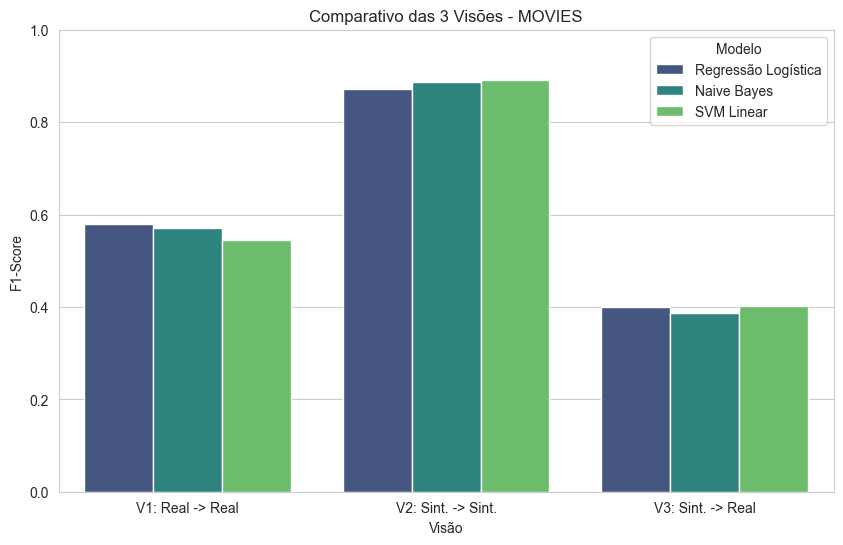

In [18]:
# 5. RELATÓRIO FINAL E SALVAMENTO
df_results = pd.DataFrame(final_metrics).round(4)
df_results.to_csv(f'resultados/metricas_3_visoes_{NICHO}.csv', index=False)

print("\n--- TABELA DE MÉTRICAS CONSOLIDADAS ---")
display(df_results)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Visão', y='F1-Score', hue='Modelo', palette='viridis')
plt.title(f'Comparativo das 3 Visões - {NICHO.upper()}')
plt.ylim(0, 1.0)
plt.savefig(f'resultados/grafico_3_visoes_{NICHO}.png')
plt.show()